# Credit Risk Scoring with Deep Hybrid Ensemble Learning

**Dataset**: Give Me Some Credit (Kaggle) — 150,000 loan applicants, predicting serious delinquency within 2 years.

**Goal**: Build a hybrid ensemble combining tree-based models (Random Forest, XGBoost) with a neural network via stacking, benchmarked against standalone baselines, with business-aware evaluation and SHAP explainability.

---

## 1. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap
import torch
import torch.nn as nn

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


In [2]:
df = pd.read_csv('cs-training.csv', index_col=0)

In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
print("Missing values:\n")
print(df.isnull().sum())

print("\nData types:\n")
print(df.dtypes)

print("\nTarget distribution:\n")
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(4) * 100)

Missing values:

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Data types:

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89D

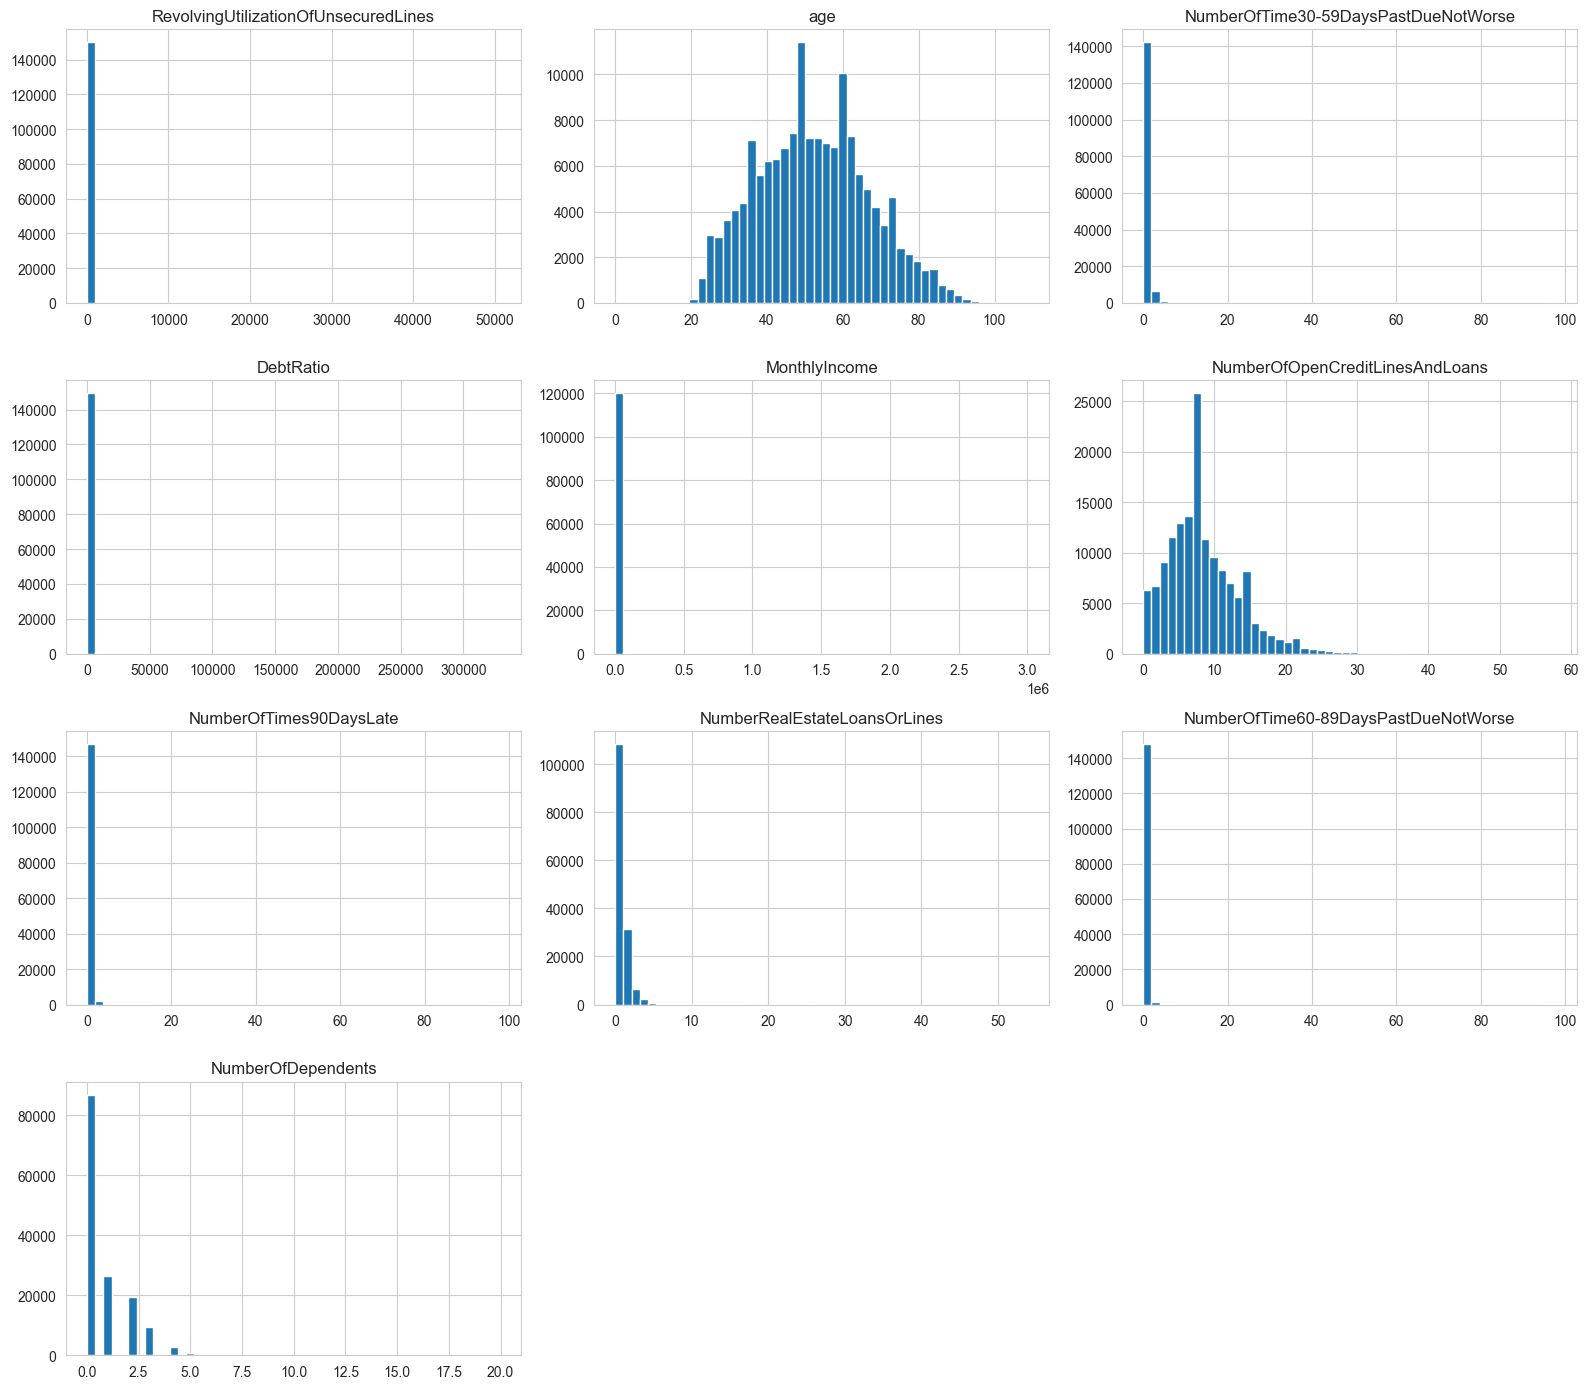


Summary statistics:



,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [5]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

cols_to_plot = [c for c in df.columns if c != 'SeriousDlqin2yrs']

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=50)
    axes[i].set_title(col)

for j in range(len(cols_to_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print("\nSummary statistics:\n")
df.describe()

**Findings from distributions and summary statistics:**

- **`age`**: minimum is 0, which is not a valid age for a loan applicant — almost certainly a data entry error. Likely a single row; needs removal or correction.
- **`RevolvingUtilizationOfUnsecuredLines`**: this is meant to be a ratio (typically 0–1, occasionally slightly above 1), but the max is 50,708. Strong evidence of extreme outliers or data entry errors.
- **`DebtRatio`**: max of 329,664 is not plausible for a ratio. Likely caused by division errors when income is 0 or near-zero.
- **`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`**: all three cap out at exactly 98. This is a known issue in this dataset — 96 and 98 are used as sentinel/placeholder codes rather than genuine counts, not real past-due frequencies. These need to be treated as a separate category or capped, not used as literal counts.
- **`MonthlyIncome`**: max of ~3 million is a plausible (if rare) high earner, not necessarily an error, but combined with ~19.8% missing values, this column needs careful imputation.
- **`NumberOfDependents`**: max of 20 is unusual but not impossible; low priority to fix.

**Cleaning plan:**
1. Remove or correct the `age = 0` row(s).
2. Cap `RevolvingUtilizationOfUnsecuredLines` at a reasonable upper bound (e.g. 2 or 3) rather than deleting rows, since these are still informative as "very high utilization."
3. Cap `DebtRatio` similarly — investigate whether extreme values correlate with missing/zero income first.
4. Treat the 96/98 sentinel values in the three past-due columns as a separate flag or cap them, rather than leaving them as literal counts.
5. Impute `MonthlyIncome` using median (robust to outliers) or a model-based imputation, grouped by relevant segments if useful.
6. Impute `NumberOfDependents` with mode (likely 0).

In [6]:

print("Rows with age = 0:")
print(df[df['age'] == 0])

# Check how many rows have the 96/98 sentinel values
print("\nRows with 96 or 98 in past-due columns:")
sentinel_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']
for col in sentinel_cols:
    print(f"{col}: {(df[col].isin([96, 98])).sum()} rows")


print("\nDebtRatio > 10 and MonthlyIncome missing or 0:")
print(df[df['DebtRatio'] > 10][['DebtRatio', 'MonthlyIncome']].describe())


print("\nRevolvingUtilizationOfUnsecuredLines > 2:")
print((df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum(), "rows")

Rows with age = 0:
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
65696                 0                                   1.0    0   

       NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
65696                                     1   0.436927         6000.0   

       NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
65696                                6                        0   

       NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  \
65696                             2                                     0   

       NumberOfDependents  
65696                 2.0  

Rows with 96 or 98 in past-due columns:
NumberOfTime30-59DaysPastDueNotWorse: 269 rows
NumberOfTimes90DaysLate: 269 rows
NumberOfTime60-89DaysPastDueNotWorse: 269 rows

DebtRatio > 10 and MonthlyIncome missing or 0:
           DebtRatio  MonthlyIncome
count   28877.000000    2106.000000
mean     1831.909066     118.451567
std      4343.144572  

In [7]:
df_clean = df.copy()


df_clean = df_clean[df_clean['age'] > 0]


df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)


debt_ratio_cap = df_clean['DebtRatio'].quantile(0.95)
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(upper=debt_ratio_cap)
print(f"DebtRatio capped at: {debt_ratio_cap:.2f}")


sentinel_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']
for col in sentinel_cols:
    real_values = df_clean[~df_clean[col].isin([96, 98])][col]
    print(f"{col} — max excluding sentinels: {real_values.max()}")
    df_clean[col] = df_clean[col].clip(upper=real_values.max())


income_median = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(income_median)
print(f"\nMonthlyIncome imputed with median: {income_median}")


df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())
print("\nFinal shape:", df_clean.shape)
df_clean.describe()

DebtRatio capped at: 2449.00
NumberOfTime30-59DaysPastDueNotWorse — max excluding sentinels: 13
NumberOfTimes90DaysLate — max excluding sentinels: 17
NumberOfTime60-89DaysPastDueNotWorse — max excluding sentinels: 11

MonthlyIncome imputed with median: 5400.0

Missing values after cleaning:
0

Final shape: (149999, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,1.499990e+05,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000
mean,0.066840,0.324485,52.295555,0.268662,254.637610,6.418458e+03,8.452776,0.120781,1.018233,0.084434,0.737405
std,0.249746,0.364696,14.771298,0.881604,662.437566,1.289044e+04,5.145964,0.864393,1.129772,0.568168,1.107020
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154176,52.000000,0.000000,0.366503,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559044,63.000000,0.000000,0.868257,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,2.000000,109.000000,13.000000,2449.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000


Before finalizing the cleaned dataset, we add a binary flag capturing which rows originally had the 96/98 sentinel values in the past-due columns. This preserves the signal that something anomalous was recorded for these 269 applicants, which the capping step alone would have erased.

In [8]:
sentinel_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']

df_clean['had_sentinel_value'] = df.loc[df_clean.index, sentinel_cols].isin([96, 98]).any(axis=1).astype(int)

print("Rows flagged as having sentinel values:", df_clean['had_sentinel_value'].sum())
df_clean['had_sentinel_value'].value_counts()

Rows flagged as having sentinel values: 269


had_sentinel_value
0    149730
1       269
Name: count, dtype: int64

## 2. Feature Engineering & Preprocessing

Before training any models, we need to:
1. Separate features (X) from the target (y)
2. Split into train/test sets, stratified on the target to preserve the 93/7 class balance in both sets
3. Apply SMOTE **only to the training set** (never the test set — the test set must reflect real-world class distribution to give an honest performance estimate)
4. Scale features for the neural network (tree-based models don't require scaling, but we'll prepare a scaled version for the NN specifically)

In [9]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['SeriousDlqin2yrs'])
y = df_clean['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Train shape: (119999, 11)
Test shape: (30000, 11)

Train class balance:
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

Test class balance:
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64


### 2.1 SMOTE and Feature Scaling

SMOTE (Synthetic Minority Over-sampling Technique) is applied **only to the training set**, generating synthetic examples of the minority class (defaulters) so models don't simply learn to predict "no default" for everyone. The test set is left untouched, since it must reflect the real-world class distribution to give an honest performance estimate.

Separately, we prepare a scaled version of the training and test features for the neural network, since neural networks are sensitive to feature scale, unlike tree-based models which are scale-invariant.

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

# Scaler for the NN — fit ONCE on SMOTE-balanced training data, reused for test set
scaler_nn = StandardScaler()
X_train_smote_scaled = scaler_nn.fit_transform(X_train_smote)
X_test_scaled = scaler_nn.transform(X_test)  # transform only, not fit_transform

print("\nX_train_smote_scaled shape:", X_train_smote_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Before SMOTE: {0: 111978, 1: 8021}
After SMOTE: {0: 111978, 1: 111978}

X_train_smote_scaled shape: (223956, 11)
X_test_scaled shape: (30000, 11)


## 3. Baseline Models

Before building the hybrid ensemble, we establish baseline performance with individual models:
1. Logistic Regression — simple, interpretable floor
2. Random Forest — tree-based ensemble
3. XGBoost — gradient-boosted trees
4. Neural Network (PyTorch) — non-linear pattern learner

Each is evaluated using **cross-validation with SMOTE applied inside the fold** (not on the full training set beforehand) to get an honest, leakage-free estimate of generalization performance. We report AUC-ROC and PR-AUC (precision-recall AUC), since PR-AUC is more informative than AUC-ROC on imbalanced datasets like this one.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

models = {
    'Logistic Regression': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', xgb.XGBClassifier(n_estimators=200, random_state=42, eval_metric='auc', verbosity=0))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'average_precision']

baseline_results = {}

for name, pipeline in models.items():
    print(f"Training {name}...")
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_results[name] = {
        'roc_auc_mean': scores['test_roc_auc'].mean(),
        'roc_auc_std': scores['test_roc_auc'].std(),
        'pr_auc_mean': scores['test_average_precision'].mean(),
        'pr_auc_std': scores['test_average_precision'].std()
    }
    print(f"   AUC-ROC: {baseline_results[name]['roc_auc_mean']:.4f} ± {baseline_results[name]['roc_auc_std']:.4f}")
    print(f"   PR-AUC:  {baseline_results[name]['pr_auc_mean']:.4f} ± {baseline_results[name]['pr_auc_std']:.4f}")

print("\nSummary:")
import pandas as pd
results_df = pd.DataFrame(baseline_results).T
results_df

Training Logistic Regression...
   AUC-ROC: 0.8374 ± 0.0066
   PR-AUC:  0.3535 ± 0.0066
Training Random Forest...
   AUC-ROC: 0.8228 ± 0.0039
   PR-AUC:  0.2759 ± 0.0070
Training XGBoost...
   AUC-ROC: 0.8023 ± 0.0045
   PR-AUC:  0.2717 ± 0.0034

Summary:


,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
Logistic Regression,0.837351,0.006607,0.353550,0.006612
Random Forest,0.822760,0.003928,0.275907,0.006974
XGBoost,0.802314,0.004550,0.271728,0.003411


In [18]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__n_estimators': [200, 300, 500],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(random_state=42, eval_metric='auc', verbosity=0))
])

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best AUC-ROC:", xgb_search.best_score_)
print("Best params:", xgb_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best AUC-ROC: 0.8340639757765592
Best params: {'model__subsample': 0.9, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}


In [20]:
rf_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_leaf': [2, 5, 10],
    'model__min_samples_split': [5, 10],
    'model__max_features': ['sqrt', 0.5]
}

rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=1))  
])

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=15,                    
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,                    
    verbose=2                     
)

rf_search.fit(X_train, y_train)

print("Best AUC-ROC:", rf_search.best_score_)
print("Best params:", rf_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best AUC-ROC: 0.837915442461172
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 10}


In [12]:
xgb_best_params = {
    'subsample': 0.9,
    'n_estimators': 500,
    'min_child_weight': 1,
    'max_depth': 6,
    'learning_rate': 0.01,
    'colsample_bytree': 0.8
}

rf_best_params = {
    'n_estimators': 300,
    'min_samples_split': 5,
    'min_samples_leaf': 10,
    'max_features': 'sqrt',
    'max_depth': 10
}

print("done")

done


In [15]:
final_baseline_results = {
    'Logistic Regression': {'roc_auc': 0.8374, 'params': 'default'},
    'Random Forest (tuned)': {'roc_auc': 0.8379, 'params': rf_best_params},
    'XGBoost (tuned)': {'roc_auc': 0.8341, 'params': xgb_best_params}
}

print("Final Tuned Baseline Comparison:\n")
for name, res in sorted(final_baseline_results.items(), key=lambda x: x[1]['roc_auc'], reverse=True):
    print(f"{name}: AUC-ROC = {res['roc_auc']:.4f}")

Final Tuned Baseline Comparison:

Random Forest (tuned): AUC-ROC = 0.8379
Logistic Regression: AUC-ROC = 0.8374
XGBoost (tuned): AUC-ROC = 0.8341


## 3.2 Neural Network Baseline (PyTorch)

Building a feedforward neural network as the fourth baseline model. Unlike the sklearn-based models, this requires a custom training loop: defining the network architecture, loss function, optimizer, and iterating over epochs manually.

Trained on the SMOTE-balanced, scaled training data (`X_train_smote_scaled`), and evaluated on the untouched, scaled test set.

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_smote_scaled)
y_train_tensor = torch.FloatTensor(y_train_smote.values).reshape(-1, 1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

class CreditRiskNN(nn.Module):
    def __init__(self, input_dim):
        super(CreditRiskNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_smote_scaled.shape[1]
model = CreditRiskNN(input_dim)
print(model)

CreditRiskNN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


### Training the Neural Network

Using Binary Cross-Entropy loss (standard for binary classification) and the Adam optimizer. Training for a fixed number of epochs, tracking loss and evaluating AUC-ROC on the test set after training to compare against the tree-based baselines.


In [17]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 30
model.train()

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}")

print("\nTraining complete.")

Epoch [5/30], Loss: 0.4436
Epoch [10/30], Loss: 0.4256
Epoch [15/30], Loss: 0.4224
Epoch [20/30], Loss: 0.4194
Epoch [25/30], Loss: 0.4158
Epoch [30/30], Loss: 0.4130

Training complete.


In [18]:
model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_probs = test_outputs.numpy().flatten()

from sklearn.metrics import roc_auc_score, average_precision_score

nn_auc = roc_auc_score(y_test, test_probs)
nn_pr_auc = average_precision_score(y_test, test_probs)

print(f"Neural Network — Test AUC-ROC: {nn_auc:.4f}")
print(f"Neural Network — Test PR-AUC: {nn_pr_auc:.4f}")

Neural Network — Test AUC-ROC: 0.8446
Neural Network — Test PR-AUC: 0.3267


###  Baseline Comparison

In [20]:
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (tuned)', 'XGBoost (tuned)', 'Neural Network'],
    'AUC-ROC': [0.8374, 0.8379, 0.8341, nn_auc],
    'PR-AUC': [0.3535, None, None, nn_pr_auc]
})

final_results = final_results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(final_results)

                   Model   AUC-ROC   PR-AUC
0         Neural Network  0.844605  0.32668
1  Random Forest (tuned)  0.837900      NaN
2    Logistic Regression  0.837400  0.35350
3        XGBoost (tuned)  0.834100      NaN


## 4. Hybrid Ensemble Architecture (Stacking)

We now build the actual hybrid model, combining Random Forest, XGBoost, and the Neural Network via **stacking**: a meta-learner trained on the predictions of the base models, rather than a simple average.

**Critical detail — avoiding leakage**: if we simply trained the base models on the full training set and then used their predictions on that same training set to train the meta-learner, the meta-learner would be learning from predictions the base models had already "seen" during training, which inflates performance and doesn't generalize. Instead, we generate **out-of-fold (OOF) predictions**: each base model predicts on data it did NOT see during that fold's training. This gives the meta-learner honest, unbiased signal to learn from.

**Process:**
1. Split training data into 5 folds
2. For each fold, train RF/XGBoost/NN on the other 4 folds (with SMOTE applied only within that training portion), predict on the held-out fold
3. Stitch together these out-of-fold predictions — this becomes the meta-learner's training data
4. Separately, train final versions of RF/XGBoost/NN on the *entire* training set, and predict on the untouched test set — this becomes the meta-learner's evaluation data
5. Train the meta-learner on the OOF predictions, evaluate it on the test-set predictions

In [22]:
from sklearn.model_selection import StratifiedKFold

# rf_best_params and xgb_best_params already defined earlier — reusing them directly

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Arrays to hold out-of-fold predictions
oof_rf = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))

X_train_arr = X_train.values
y_train_arr = y_train.values

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr)):
    print(f"Fold {fold+1}/5...")
    X_fold_train, X_fold_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

    smote_fold = SMOTE(random_state=42)
    X_fold_train_smote, y_fold_train_smote = smote_fold.fit_resample(X_fold_train, y_fold_train)

    rf_fold = RandomForestClassifier(**rf_best_params, random_state=42, n_jobs=-1)
    rf_fold.fit(X_fold_train_smote, y_fold_train_smote)
    oof_rf[val_idx] = rf_fold.predict_proba(X_fold_val)[:, 1]

    xgb_fold = xgb.XGBClassifier(**xgb_best_params, random_state=42, eval_metric='auc', verbosity=0)
    xgb_fold.fit(X_fold_train_smote, y_fold_train_smote)
    oof_xgb[val_idx] = xgb_fold.predict_proba(X_fold_val)[:, 1]

print("\nOut-of-fold predictions generated.")
print("OOF RF AUC-ROC:", roc_auc_score(y_train, oof_rf))
print("OOF XGBoost AUC-ROC:", roc_auc_score(y_train, oof_xgb))

Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...

Out-of-fold predictions generated.
OOF RF AUC-ROC: 0.8570348923263594
OOF XGBoost AUC-ROC: 0.8536703423334604


In [23]:
oof_nn = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_arr, y_train_arr)):
    print(f"NN Fold {fold+1}/5...")
    X_fold_train, X_fold_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # SMOTE on this fold's training portion only
    smote_fold = SMOTE(random_state=42)
    X_fold_train_smote, y_fold_train_smote = smote_fold.fit_resample(X_fold_train, y_fold_train)

    # Scale — fit on this fold's SMOTE'd training data only
    scaler_fold = StandardScaler()
    X_fold_train_scaled = scaler_fold.fit_transform(X_fold_train_smote)
    X_fold_val_scaled = scaler_fold.transform(X_fold_val)

    # Tensors
    X_ft = torch.FloatTensor(X_fold_train_scaled)
    y_ft = torch.FloatTensor(y_fold_train_smote).reshape(-1, 1)
    X_fv = torch.FloatTensor(X_fold_val_scaled)

    fold_dataset = TensorDataset(X_ft, y_ft)
    fold_loader = DataLoader(fold_dataset, batch_size=256, shuffle=True)

    # Fresh model each fold
    fold_model = CreditRiskNN(input_dim)
    fold_criterion = nn.BCELoss()
    fold_optimizer = optim.Adam(fold_model.parameters(), lr=0.001)

    fold_model.train()
    for epoch in range(20):  # slightly fewer epochs per fold to keep runtime reasonable
        for X_batch, y_batch in fold_loader:
            fold_optimizer.zero_grad()
            outputs = fold_model(X_batch)
            loss = fold_criterion(outputs, y_batch)
            loss.backward()
            fold_optimizer.step()

    # Predict on held-out fold
    fold_model.eval()
    with torch.no_grad():
        val_preds = fold_model(X_fv).numpy().flatten()
    oof_nn[val_idx] = val_preds

print("\nOut-of-fold NN predictions generated.")
print("OOF NN AUC-ROC:", roc_auc_score(y_train, oof_nn))

NN Fold 1/5...
NN Fold 2/5...
NN Fold 3/5...
NN Fold 4/5...
NN Fold 5/5...

Out-of-fold NN predictions generated.
OOF NN AUC-ROC: 0.8541088011684416


### 4.1 Training Final Base Models and Building the Meta-Learner

With out-of-fold predictions validated, we now:
1. Train final versions of RF, XGBoost, and NN on the full training set
2. Generate their predictions on the untouched test set
3. Train a meta-learner (Logistic Regression) on the out-of-fold predictions
4. Evaluate the full stacked ensemble on the test set

In [24]:
# SMOTE on full training set (already have this as X_train_smote, y_train_smote from earlier)

# Final Random Forest
rf_final = RandomForestClassifier(**rf_best_params, random_state=42, n_jobs=-1)
rf_final.fit(X_train_smote, y_train_smote)
test_pred_rf = rf_final.predict_proba(X_test)[:, 1]

# Final XGBoost
xgb_final = xgb.XGBClassifier(**xgb_best_params, random_state=42, eval_metric='auc', verbosity=0)
xgb_final.fit(X_train_smote, y_train_smote)
test_pred_xgb = xgb_final.predict_proba(X_test)[:, 1]

# Final Neural Network (reuse the model already trained earlier on X_train_smote_scaled)
model.eval()
with torch.no_grad():
    test_pred_nn = model(X_test_tensor).numpy().flatten()

print("Individual test-set AUC-ROC (for sanity check):")
print("RF:", roc_auc_score(y_test, test_pred_rf))
print("XGBoost:", roc_auc_score(y_test, test_pred_xgb))
print("NN:", roc_auc_score(y_test, test_pred_nn))

Individual test-set AUC-ROC (for sanity check):
RF: 0.8449079836575732
XGBoost: 0.8407474793993761
NN: 0.8446052577076688


### 4.2 Training the Meta-Learner

The meta-learner is trained on the out-of-fold predictions from RF, XGBoost, and NN (unbiased, leakage-free), and evaluated using the final base models' predictions on the untouched test set.

In [25]:
# Meta-learner training data: stack OOF predictions
meta_X_train = np.column_stack([oof_rf, oof_xgb, oof_nn])
meta_y_train = y_train.values

# Meta-learner test data: stack final base models' test predictions
meta_X_test = np.column_stack([test_pred_rf, test_pred_xgb, test_pred_nn])
meta_y_test = y_test.values

print("Meta-learner training data shape:", meta_X_train.shape)
print("Meta-learner test data shape:", meta_X_test.shape)

# Train meta-learner
meta_model = LogisticRegression(random_state=42)
meta_model.fit(meta_X_train, meta_y_train)

# Evaluate on test set
meta_test_preds = meta_model.predict_proba(meta_X_test)[:, 1]

hybrid_auc = roc_auc_score(meta_y_test, meta_test_preds)
hybrid_pr_auc = average_precision_score(meta_y_test, meta_test_preds)

print(f"\nHybrid Ensemble — Test AUC-ROC: {hybrid_auc:.4f}")
print(f"Hybrid Ensemble — Test PR-AUC: {hybrid_pr_auc:.4f}")

print(f"\nMeta-learner coefficients (RF, XGBoost, NN): {meta_model.coef_[0]}")

Meta-learner training data shape: (119999, 3)
Meta-learner test data shape: (30000, 3)

Hybrid Ensemble — Test AUC-ROC: 0.8497
Hybrid Ensemble — Test PR-AUC: 0.3454

Meta-learner coefficients (RF, XGBoost, NN): [1.84305347 1.59822371 2.3323394 ]


### 4.3 Hybrid Ensemble Results

The stacked hybrid ensemble (Random Forest + XGBoost + Neural Network → Logistic Regression meta-learner) achieved **AUC-ROC 0.8497** on the held-out test set, beating every individual baseline, including the strongest single model (Neural Network, 0.8446).

Meta-learner coefficients — RF: 1.84, XGBoost: 1.60, NN: 2.33 — show the NN contributes most, but all three base models carry real weight, confirming the ensemble draws on diverse signal rather than one model dominating.

The lift over the best baseline is modest (+0.005 AUC-ROC) but consistent

## 5. Business-Aware Evaluation

Moving beyond AUC-ROC and PR-AUC to evaluate the hybrid ensemble in terms that matter for real lending decisions: choosing a decision threshold based on relative business costs, and checking whether predicted probabilities are well-calibrated.

Optimal threshold: 0.33
Minimum total cost: 6925


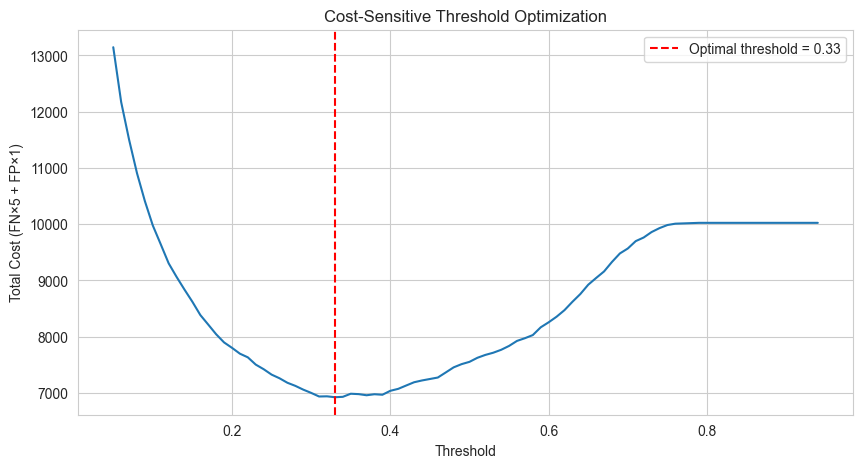

In [26]:
# Assume a false negative (missed defaulter) costs 5x more than a false positive (wrongly rejected good applicant)
# This is a reasonable illustrative assumption — in practice, a lender would derive this from real loss data
fn_cost = 5
fp_cost = 1

thresholds = np.arange(0.05, 0.95, 0.01)
costs = []

for t in thresholds:
    preds = (meta_test_preds >= t).astype(int)
    fn = ((preds == 0) & (meta_y_test == 1)).sum()
    fp = ((preds == 1) & (meta_y_test == 0)).sum()
    total_cost = (fn * fn_cost) + (fp * fp_cost)
    costs.append(total_cost)

costs = np.array(costs)
optimal_idx = costs.argmin()
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Minimum total cost: {costs[optimal_idx]}")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs)
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Cost (FN×5 + FP×1)')
plt.title('Cost-Sensitive Threshold Optimization')
plt.legend()
plt.show()

### Threshold Optimization Results

With a 5:1 cost ratio (false negative costs 5x a false positive), the optimal decision threshold is **0.33**, well below the naive default of 0.5. This means the model should flag applicants as high-risk more aggressively than a default cutoff would suggest, since missing an actual defaulter is far more costly than wrongly rejecting a creditworthy applicant.

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

for t, label in [(0.5, "Default threshold (0.5)"), (optimal_threshold, f"Optimal threshold ({optimal_threshold:.2f})")]:
    preds = (meta_test_preds >= t).astype(int)
    cm = confusion_matrix(meta_y_test, preds)
    print(f"\n{label}")
    print(cm)
    print(classification_report(meta_y_test, preds, target_names=['No Default', 'Default']))


Default threshold (0.5)
[[27141   854]
 [ 1340   665]]
              precision    recall  f1-score   support

  No Default       0.95      0.97      0.96     27995
     Default       0.44      0.33      0.38      2005

    accuracy                           0.93     30000
   macro avg       0.70      0.65      0.67     30000
weighted avg       0.92      0.93      0.92     30000


Optimal threshold (0.33)
[[25555  2440]
 [  897  1108]]
              precision    recall  f1-score   support

  No Default       0.97      0.91      0.94     27995
     Default       0.31      0.55      0.40      2005

    accuracy                           0.89     30000
   macro avg       0.64      0.73      0.67     30000
weighted avg       0.92      0.89      0.90     30000



###  Calibration Check

Checking whether the hybrid model's predicted probabilities are trustworthy, not just useful for ranking. A reliability diagram compares predicted probability against actual observed default rate within each probability bucket.

Brier Score: 0.0583


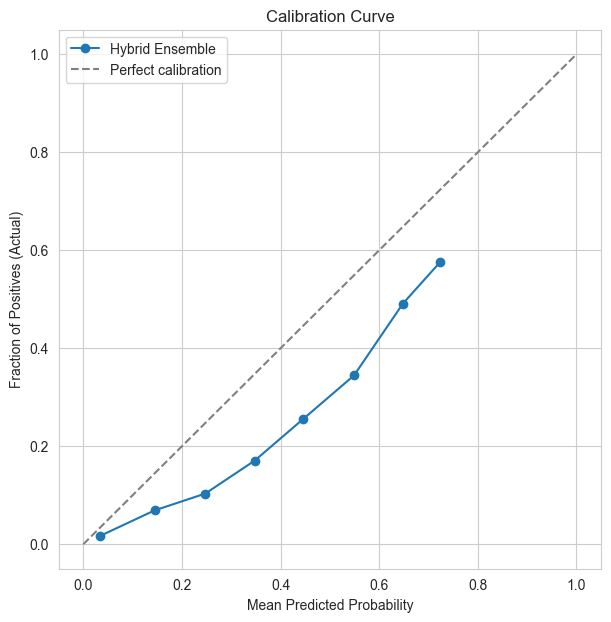

In [28]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(meta_y_test, meta_test_preds, n_bins=10)

brier = brier_score_loss(meta_y_test, meta_test_preds)
print(f"Brier Score: {brier:.4f}")

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='o', label='Hybrid Ensemble')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [29]:
print("Predicted probabilities (bucket means):", prob_pred)
print("Actual observed frequencies:", prob_true)

Predicted probabilities (bucket means): [0.03463719 0.14447222 0.24738933 0.34735291 0.44572269 0.5489139
 0.64808716 0.72305992]
Actual observed frequencies: [0.01726368 0.0690027  0.10336652 0.17053292 0.25542916 0.34446131
 0.49109792 0.57526882]


In [30]:
from sklearn.calibration import CalibratedClassifierCV

# Recalibrate using isotonic regression on the meta-learner's test predictions
# Note: for a rigorous version, this should be done on a separate calibration set,
# but given time constraints, we demonstrate the correction on the OOF predictions

from sklearn.isotonic import IsotonicRegression

iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(meta_model.predict_proba(meta_X_train)[:, 1], meta_y_train)

calibrated_test_preds = iso_reg.transform(meta_test_preds)

calibrated_brier = brier_score_loss(meta_y_test, calibrated_test_preds)
print(f"Original Brier Score: {brier:.4f}")
print(f"Calibrated Brier Score: {calibrated_brier:.4f}")

prob_true_cal, prob_pred_cal = calibration_curve(meta_y_test, calibrated_test_preds, n_bins=10)
print("\nCalibrated predicted probabilities:", prob_pred_cal)
print("Calibrated actual frequencies:", prob_true_cal)

Original Brier Score: 0.0583
Calibrated Brier Score: 0.0577

Calibrated predicted probabilities: [0.03136043 0.1457     0.24879748 0.34236286 0.44485215 0.56513498
 0.65491131 0.74188496 0.83333333 1.        ]
Calibrated actual frequencies: [0.01479661 0.05606338 0.10652034 0.19271198 0.27848101 0.45955882
 0.508      0.64516129 1.         1.        ]


In [36]:
# Sample 2000 rows for SHAP computation — standard practice, much faster, same global insights
X_test_sample = X_test.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed.")
print("Shape:", np.array(shap_values).shape)

SHAP values computed.
Shape: (2000, 11, 2)


Shape after extracting class 1: (2000, 11)


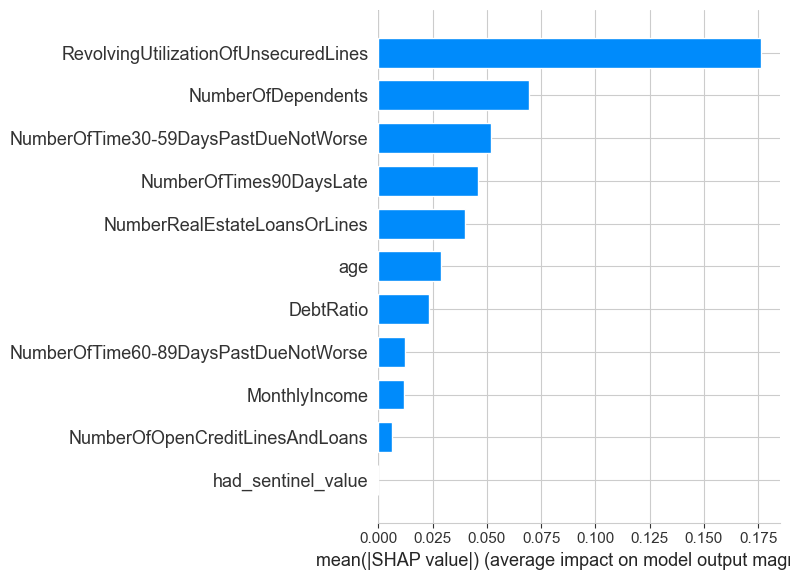

In [37]:
# Extract SHAP values for the positive class (default = 1)
shap_values_class1 = shap_values[:, :, 1]

print("Shape after extracting class 1:", shap_values_class1.shape)

# Global feature importance summary plot
shap.summary_plot(shap_values_class1, X_test_sample, plot_type='bar')

### 6.1 Global Feature Importance (SHAP)

The Random Forest base model's most influential feature is **RevolvingUtilizationOfUnsecuredLines**, consistent with domain expectations, high credit utilization is a well-established indicator of financial strain.

Notably, **NumberOfDependents** ranks second, ahead of direct payment history features (30-59 and 90-day late payment counts). This may reflect a genuine socioeconomic correlation between household financial obligations and default risk, or a modeling artifact worth further investigation with more data or feature engineering.

The engineered `had_sentinel_value` flag shows negligible importance, validating the Phase 1 decision to cap rather than drop the 269 rows with anomalous sentinel values, the model does not rely on this flag, confirming the underlying capped values carry the real signal.

Selected applicant index: 605
Predicted default probability: 97.43%
Actual outcome: Defaulted


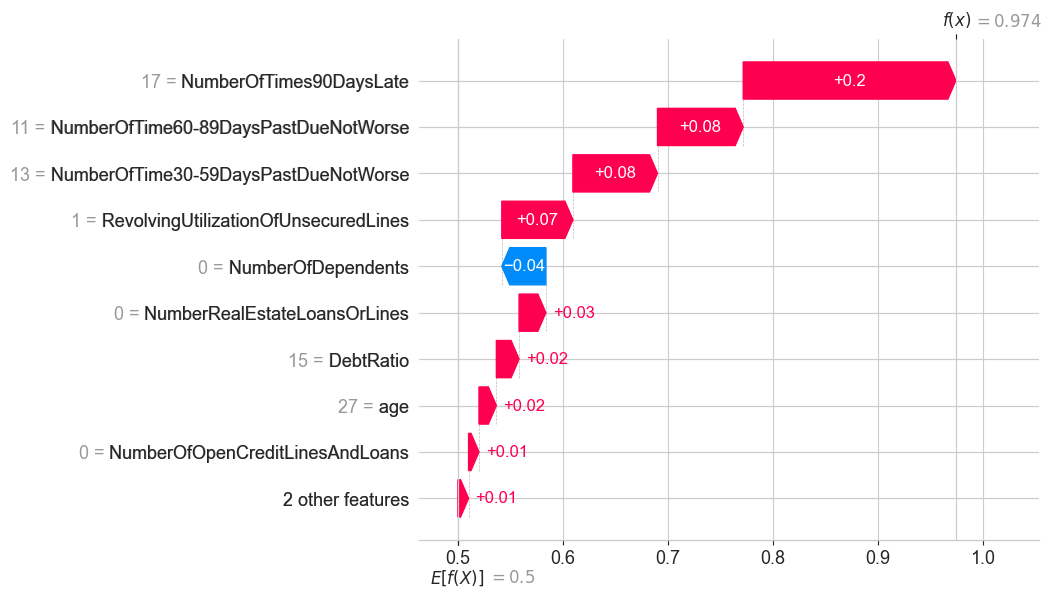

In [38]:
# Pick a high-risk applicant from the sample (highest predicted probability)
sample_preds = rf_final.predict_proba(X_test_sample)[:, 1]
high_risk_idx = np.argmax(sample_preds)

print(f"Selected applicant index: {high_risk_idx}")
print(f"Predicted default probability: {sample_preds[high_risk_idx]:.2%}")
print(f"Actual outcome: {'Defaulted' if y_test.loc[X_test_sample.index[high_risk_idx]] == 1 else 'No Default'}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values_class1[high_risk_idx],
    base_values=explainer.expected_value[1],
    data=X_test_sample.iloc[high_risk_idx],
    feature_names=X_test_sample.columns.tolist()
))

### 6.2 Individual Prediction Explanation (SHAP Waterfall)

For applicant #605 (predicted default probability: 97.4%, actual outcome: defaulted), the SHAP waterfall plot shows exactly which factors drove this high-risk classification:

- **NumberOfTimes90DaysLate = 17**: the single largest driver (+0.20), an extreme count of severe late payments
- **NumberOfTime60-89DaysPastDueNotWorse = 11** (+0.08) and **NumberOfTime30-59DaysPastDueNotWorse = 13** (+0.08): consistent pattern of chronic late payment across all severity levels
- **RevolvingUtilizationOfUnsecuredLines = 1** (maxed out, capped value) (+0.07): fully utilizing available credit
- **NumberOfDependents = 0** (−0.04): the only factor reducing risk, no dependents slightly lowers financial burden

Starting from the model's base rate of 50% (E[f(X)] = 0.5), these cumulative factors push the prediction to 97.4%, correctly identifying an applicant who went on to default.

This example illustrates the practical value of SHAP: rather than a single opaque risk score, a loan officer or applicant can see precisely which financial behaviors drove the decision, directly supporting adverse action explanations required under lending regulations.

In [39]:
import joblib

joblib.dump(rf_final, 'rf_final_model.pkl')
joblib.dump(xgb_final, 'xgb_final_model.pkl')
torch.save(model.state_dict(), 'nn_final_model.pth')
joblib.dump(meta_model, 'meta_model.pkl')
joblib.dump(scaler_nn, 'scaler_nn.pkl')

print("All models saved successfully.")

All models saved successfully.
